In [1]:
import pandas as pd
buyhold_df = pd.read_csv("buynhold_df.csv")
strategy_df = pd.read_csv("rotation_strategy_df.csv")

In [2]:
# ========== 按日期对齐balance列 ==========
# 找日期列
strategy_date_col = [col for col in strategy_df.columns if col.lower() in ['datetime', 'date']][0]
buyhold_date_col = [col for col in buyhold_df.columns if col.lower() in ['datetime', 'date']][0]

# 转换日期
strategy_df[strategy_date_col] = pd.to_datetime(strategy_df[strategy_date_col])
buyhold_df[buyhold_date_col] = pd.to_datetime(buyhold_df[buyhold_date_col])

# 使用merge按日期对齐 strategy_df 和 buyhold_df
result = pd.merge(
    strategy_df[[strategy_date_col, 'balance']],
    buyhold_df[[buyhold_date_col, 'balance']],
    left_on=strategy_date_col,
    right_on=buyhold_date_col,
    how='inner'  # 只保留两者都有的日期
)

# 重命名列
result.columns = ['date', 'strategy_balance', 'buyhold_balance']

# 按日期排序
result = result.sort_values('date').reset_index(drop=True)

print(f"对齐后数据量: {len(result)} 行")
print(f"日期范围: {result['date'].min()} 到 {result['date'].max()}")
result_all_origin = result.copy()

对齐后数据量: 1587 行
日期范围: 2019-11-11 00:00:00 到 2026-05-29 00:00:00


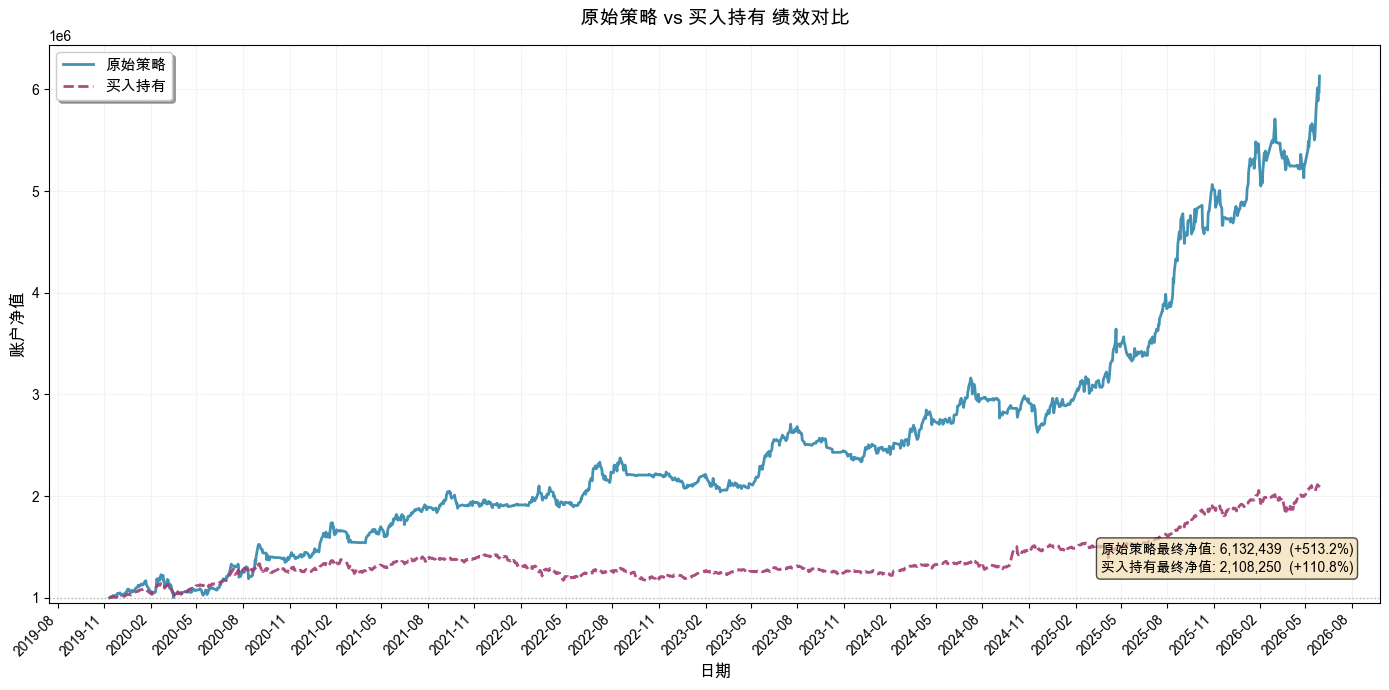

In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ========== 绘制两条balance曲线对比图 ==========
fig, ax = plt.subplots(figsize=(14, 7))

# 绘制两条曲线
ax.plot(result['date'], result['strategy_balance'], 
        label='原始策略', linewidth=2, color='#2E86AB', alpha=0.9)
ax.plot(result['date'], result['buyhold_balance'], 
        label='买入持有', linewidth=2, color='#A23B72', alpha=0.9, linestyle='--')

# 设置标签和标题
ax.set_xlabel('日期', fontsize=12, fontweight='bold')
ax.set_ylabel('账户净值', fontsize=12, fontweight='bold')
ax.set_title('原始策略 vs 买入持有 绩效对比', fontsize=14, fontweight='bold', pad=15)

# 格式化x轴日期
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # 每3个月显示一个刻度
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 添加图例
ax.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)

# 添加网格
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# 初始资金参考线
initial_capital = result['strategy_balance'].iloc[0] if not result.empty else 1000000
ax.axhline(y=initial_capital, color='gray', linestyle=':', 
           linewidth=1, alpha=0.5, label=f'初始资金: {initial_capital:,.0f}')

# 自动调整y轴
all_balances = [result['strategy_balance'], result['buyhold_balance']]
ax.set_ylim(bottom=min([b.min() for b in all_balances]) * 0.95,
            top=max([b.max() for b in all_balances]) * 1.05)

# 计算最终收益
final_strategy = result['strategy_balance'].iloc[-1]
final_buyhold = result['buyhold_balance'].iloc[-1]

strategy_return = (final_strategy / initial_capital - 1) * 100
buyhold_return = (final_buyhold / initial_capital - 1) * 100

# 在图表上添加文本标注
textstr = (f'原始策略最终净值: {final_strategy:,.0f}  ({strategy_return:+.1f}%)\n'
           f'买入持有最终净值: {final_buyhold:,.0f}  ({buyhold_return:+.1f}%)')
props = dict(boxstyle='round', facecolor='wheat', alpha=0.7)
ax.text(0.98, 0.05, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', horizontalalignment='right', bbox=props)

# 调整布局
plt.tight_layout()
plt.show()

In [4]:
result_compare = result_all_origin.filter(items=['date', 'strategy_balance', 'buyhold_balance'])
result_all_origin
result_compare

,date,strategy_balance,buyhold_balance
0,2019-11-11,1.000000e+06,1.000000e+06
1,2019-11-12,1.005509e+06,9.996850e+05
2,2019-11-13,1.005844e+06,1.001919e+06
3,2019-11-14,1.008197e+06,1.004413e+06
4,2019-11-15,1.012566e+06,1.001833e+06
...,...,...,...
1582,2026-05-25,6.015431e+06,2.112786e+06
1583,2026-05-26,5.887279e+06,2.101475e+06
1584,2026-05-27,5.993144e+06,2.099901e+06
1585,2026-05-28,5.968070e+06,2.096974e+06


In [5]:
import numpy as np
import pandas as pd
from scipy import stats


def calculate_performance_metrics(result_all, risk_free_rate=0.03):
    """
    计算策略绩效指标（按vnpy框架定义）
    
    参考：vnpy BacktestingEngine.calculate_statistics() 实现
    https://deepwiki.com/vnpy/vnpy/5.5-performance-metrics-and-visualization
    """
    
    # ========== 1. 计算收益率 ==========
    # 算术收益率（vnpy标准：用于波动率、夏普等）
    result_all['strategy_ret'] = result_all['strategy_balance'] / result_all['strategy_balance'].shift(1) - 1
    result_all['buyhold_ret'] = result_all['buyhold_balance'] / result_all['buyhold_balance'].shift(1) - 1
    
    # 对数收益率（用于回归分析Alpha/Beta）
    result_all['strategy_log_ret'] = np.log(result_all['strategy_balance'] / result_all['strategy_balance'].shift(1))
    result_all['buyhold_log_ret'] = np.log(result_all['buyhold_balance'] / result_all['buyhold_balance'].shift(1))
    
    result_all = result_all.dropna()
    
    trading_days = 252
    total_days = len(result_all)
    
    # ========== 2. 年化收益（vnpy定义：几何复利） ==========
    # 来源：vnpy BacktestingEngine.calculate_statistics()
    # annual_return = (end_balance / start_balance) ** (252 / total_days) - 1
    strategy_ann_return = (result_all['strategy_balance'].iloc[-1] / 
                           result_all['strategy_balance'].iloc[0]) ** (trading_days / total_days) - 1
    
    buyhold_ann_return = (result_all['buyhold_balance'].iloc[-1] / 
                          result_all['buyhold_balance'].iloc[0]) ** (trading_days / total_days) - 1
    
    # 总收益率（vnpy也输出此指标）
    strategy_total_return = (result_all['strategy_balance'].iloc[-1] / 
                             result_all['strategy_balance'].iloc[0]) - 1
    buyhold_total_return = (result_all['buyhold_balance'].iloc[-1] / 
                            result_all['buyhold_balance'].iloc[0]) - 1
    
    # ========== 3. 年化波动率（vnpy定义：算术收益率标准差 × √252） ==========
    # 来源：vnpy BacktestingEngine.calculate_statistics()
    # annual_vol = daily_return_std * sqrt(252)
    strategy_ann_vol = result_all['strategy_ret'].std() * np.sqrt(trading_days)
    buyhold_ann_vol = result_all['buyhold_ret'].std() * np.sqrt(trading_days)
    
    # ========== 4. 夏普比率（按你的要求：保持不变） ==========
    # vnpy公式：(annual_return - risk_free) / annual_vol
    # 你使用的是：日均收益×252 / (日收益标准差×√252)
    strategy_mean = result_all['strategy_ret'].mean()
    strategy_std = result_all['strategy_ret'].std()
    buyhold_mean = result_all['buyhold_ret'].mean()
    buyhold_std = result_all['buyhold_ret'].std()
    
    sharpe_strategy = (strategy_mean * trading_days) / (strategy_std * np.sqrt(trading_days))
    sharpe_buyhold = (buyhold_mean * trading_days) / (buyhold_std * np.sqrt(trading_days))
    
    # ========== 5. 回归分析 (Alpha和Beta) ==========
    X = result_all['buyhold_log_ret'].values
    y = result_all['strategy_log_ret'].values
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(X, y)
    
    beta = slope
    alpha_daily = intercept
    # vnpy定义：Alpha是回归截距，年化使用指数转换
    # 来源：标准CAPM模型 Alpha年化 = exp(日Alpha × 252) - 1
    alpha_annual = np.exp(alpha_daily * trading_days) - 1
    r_squared = r_value ** 2
    
    # ========== 6. 信息比率（vnpy定义：超额收益的均值/标准差 × √252） ==========
    # 来源：vnpy BacktestingEngine.calculate_statistics()
    # 注意：vnpy中信息比率使用超额收益(策略-基准)，而非回归残差
    result_all['excess_return'] = result_all['strategy_log_ret'] - result_all['buyhold_log_ret']
    excess_mean = result_all['excess_return'].mean()
    excess_std = result_all['excess_return'].std()
    info_ratio = (excess_mean / excess_std * np.sqrt(trading_days)) if excess_std > 0 else np.nan
    
    # ========== 7. 最大回撤（vnpy定义） ==========
    def calc_max_drawdown(balance_series):
        """vnpy标准：最大回撤 = min((净值 - 累计最大值) / 累计最大值)"""
        cummax = balance_series.expanding().max()
        drawdown = (balance_series - cummax) / cummax
        return drawdown.min()
    
    def calc_max_drawdown_duration(balance_series):
        """计算最大回撤持续天数"""
        cummax = balance_series.expanding().max()
        drawdown = (balance_series - cummax) / cummax
        
        max_duration = 0
        current = 0
        
        for i in range(len(drawdown)):
            if drawdown.iloc[i] < 0:
                current += 1
                max_duration = max(max_duration, current)
            else:
                current = 0
        
        return max_duration
    
    max_dd_strategy = calc_max_drawdown(result_all['strategy_balance'])
    max_dd_buyhold = calc_max_drawdown(result_all['buyhold_balance'])
    max_dd_duration = calc_max_drawdown_duration(result_all['strategy_balance'])
    
    # ========== 8. 收益回撤比（vnpy定义：总收益率/最大回撤绝对值） ==========
    # 来源：vnpy BacktestingEngine.calculate_statistics()
    # vnpy中称为 "Return Drawdown Ratio"
    return_drawdown_ratio = strategy_total_return / abs(max_dd_strategy) if max_dd_strategy != 0 else np.nan
    
    # ========== 9. 日级别统计 ==========
    # 来源：vnpy BacktestingEngine.calculate_statistics()
    profit_days = (result_all['strategy_ret'] > 0).sum()
    loss_days = (result_all['strategy_ret'] < 0).sum()
    
    # ========== 整理结果 ==========
    results = {
        '基本信息': {
            '总交易日': total_days,
            '盈利天数': profit_days,
            '亏损天数': loss_days,
            '起始资金': result_all['strategy_balance'].iloc[0],
            '结束资金': result_all['strategy_balance'].iloc[-1],
        },
        '年化收益': {
            '策略': strategy_ann_return,
            '基准': buyhold_ann_return,
        },
        '总收益率': {
            '策略': strategy_total_return,
            '基准': buyhold_total_return,
        },
        '年化波动率': {
            '策略': strategy_ann_vol,
            '基准': buyhold_ann_vol,
        },
        '夏普比率': {
            '策略': sharpe_strategy,
            '基准': sharpe_buyhold,
        },
        '最大回撤': {
            '策略': max_dd_strategy,
            '基准': max_dd_buyhold,
            '回撤持续天数': max_dd_duration,
        },
        'Alpha和Beta': {
            'Alpha (年化)': alpha_annual,
            'Beta': beta,
            'R-squared': r_squared,
            'P-value': p_value,
        },
        '其他指标': {
            '信息比率': info_ratio,
            '收益回撤比': return_drawdown_ratio,
        },
        '日频数据': {
            '策略日均收益(算术)': strategy_mean,
            '策略日收益标准差(算术)': strategy_std,
            '基准日均收益(算术)': buyhold_mean,
            '基准日收益标准差(算术)': buyhold_std,
        }
    }
    
    return results

def print_performance_metrics(metrics):

    """格式化打印绩效指标"""
    print("=" * 70)
    print("📊 策略绩效分析报告 (按vnpy框架定义)")
    print("=" * 70)
    
    # 基本信息
    print("\n📋 基本信息:")
    for key, value in metrics['基本信息'].items():
        if '资金' in key:
            print(f"  {key}: {value:,.2f}")
        else:
            print(f"  {key}: {value}")
    
    # 年化收益
    print("\n💰 年化收益:")
    for key, value in metrics['年化收益'].items():
        print(f"  {key}: {value:.2%}")
    
    # 总收益率
    print("\n📈 总收益率:")
    for key, value in metrics['总收益率'].items():
        print(f"  {key}: {value:.2%}")
    
    # 年化波动率
    print("\n📊 年化波动率:")
    for key, value in metrics['年化波动率'].items():
        print(f"  {key}: {value:.2%}")
    
    # 夏普比率
    print("\n📐 夏普比率:")
    for key, value in metrics['夏普比率'].items():
        print(f"  {key}: {value:.3f}")
    
    # 最大回撤
    print("\n📉 最大回撤:")
    for key, value in metrics['最大回撤'].items():
        if key == '回撤持续天数':
            print(f"  {key}: {value} 天")
        else:
            print(f"  {key}: {value:.2%}")
    
    # Alpha和Beta
    print("\n📐 Alpha和Beta (CAPM模型):")
    print(f"  Alpha (年化): {metrics['Alpha和Beta']['Alpha (年化)']:.2%}")
    print(f"  Beta: {metrics['Alpha和Beta']['Beta']:.3f}")
    print(f"  R-squared: {metrics['Alpha和Beta']['R-squared']:.3f}")
    print(f"  P-value: {metrics['Alpha和Beta']['P-value']:.4f}")
    
    # 其他指标
    print("\n🔍 其他指标:")
    print(f"  信息比率: {metrics['其他指标']['信息比率']:.3f}")
    print(f"  收益回撤比: {metrics['其他指标']['收益回撤比']:.3f}")
    
    # 日频数据
    print("\n📋 日频数据:")
    for key, value in metrics['日频数据'].items():
        print(f"  {key}: {value:.6f}")

metrics = calculate_performance_metrics(result_all = result_compare, risk_free_rate=0.03)
print_performance_metrics(metrics)

📊 策略绩效分析报告 (按vnpy框架定义)

📋 基本信息:
  总交易日: 1586
  盈利天数: 840
  亏损天数: 708
  起始资金: 1,005,508.72
  结束资金: 6,132,439.19

💰 年化收益:
  策略: 33.28%
  基准: 12.59%

📈 总收益率:
  策略: 509.88%
  基准: 110.89%

📊 年化波动率:
  策略: 21.26%
  基准: 12.71%

📐 夏普比率:
  策略: 1.463
  基准: 0.996

📉 最大回撤:
  策略: -18.29%
  基准: -18.11%
  回撤持续天数: 187 天

📐 Alpha和Beta (CAPM模型):
  Alpha (年化): 19.98%
  Beta: 0.894
  R-squared: 0.286
  P-value: 0.0000

🔍 其他指标:
  信息比率: 0.939
  收益回撤比: 27.874

📋 日频数据:
  策略日均收益(算术): 0.001234
  策略日收益标准差(算术): 0.013391
  基准日均收益(算术): 0.000503
  基准日收益标准差(算术): 0.008010


/var/folders/w4/mkt1vn7n1t92zjgxb87ch6dw0000gn/T/ipykernel_35836/948461292.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_all['excess_return'] = result_all['strategy_log_ret'] - result_all['buyhold_log_ret']
